In [ ]:
!pip install -q transformers datasets tokenizers sentencepiece accelerate scikit-learn seaborn matplotlib

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import random
from datasets import load_dataset, Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight

# Set random seeds
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Device: Tesla T4


In [ ]:
print("Downloading Dataset...")
try:
    # Try loading from HuggingFace first
    dataset_raw = load_dataset("tamilmixsentiment")
    df = pd.DataFrame(dataset_raw['train'])
except Exception:
    # Fallback to GitHub
    url = "https://raw.githubusercontent.com/bharathichezhiyan/TamilMixSentiment/master/tamilmixsentiment_train.csv"
    df = pd.read_csv(url, sep="\t", names=["label", "text"])

# Clean Labels
label_map = {
    'positive': 0, 'pos': 0, '0': 0, 0: 0,
    'negative': 1, 'neg': 1, '1': 1, 1: 1,
    'mixed_feelings': 2, 'mixed': 2, '2': 2, 2: 2,
    'unknown_state': 3, 'unknown': 3, '3': 3, 3: 3,
    'not-tamil': 4, 'not tamil': 4, '4': 4, 4: 4
}

def clean_label(val):
    s = str(val).strip().lower()
    return label_map.get(s, label_map.get(val, 3))

df['label'] = df['label'].apply(clean_label)
df = df.dropna(subset=['text', 'label'])
df['text'] = df['text'].astype(str)

print(f"Data Loaded: {len(df)} samples")
print(df['label'].value_counts())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/507k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/60.3k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/141k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11335 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1260 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3149 [00:00<?, ? examples/s]

Data Loaded: 11335 samples
label
0    7627
1    1448
2    1283
3     609
4     368
Name: count, dtype: int64


In [ ]:
def simple_augment(text):
    """
    Randomly swaps two words in the sentence.
    Acts as noise injection to prevent overfitting.
    """
    words = text.split()
    if len(words) > 3:
        idx1, idx2 = random.sample(range(len(words)), 2)
        words[idx1], words[idx2] = words[idx2], words[idx1]
    return " ".join(words)

print("🚀 Applying Synthetic Augmentation...")

# Get class counts
label_counts = df['label'].value_counts()
target_size = label_counts.max() # We want all classes to match the majority

balanced_dfs = []

for label, count in label_counts.items():
    df_class = df[df['label'] == label]

    if count < target_size:
        # Calculate how many synthetic samples we need
        n_needed = target_size - count

        # 1. Take samples from existing data
        df_to_augment = df_class.sample(n_needed, replace=True, random_state=SEED)

        # 2. Mutate them (Word Swap) -> This creates NEW data
        df_to_augment['text'] = df_to_augment['text'].apply(simple_augment)

        # 3. Combine original + synthetic
        balanced_dfs.append(pd.concat([df_class, df_to_augment]))
        print(f"  Class {label}: {count} -> {target_size} (Added {n_needed} synthetic)")
    else:
        balanced_dfs.append(df_class)
        print(f"  Class {label}: {count} (Majority - Unchanged)")

# Combine and Shuffle
df_balanced = pd.concat(balanced_dfs).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"\nFinal Training Size: {len(df_balanced)}")

🚀 Applying Synthetic Augmentation...
  Class 0: 7627 (Majority - Unchanged)
  Class 1: 1448 -> 7627 (Added 6179 synthetic)
  Class 2: 1283 -> 7627 (Added 6344 synthetic)
  Class 3: 609 -> 7627 (Added 7018 synthetic)
  Class 4: 368 -> 7627 (Added 7259 synthetic)

Final Training Size: 38135


In [ ]:
MODEL_NAME = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

ds = Dataset.from_pandas(df_balanced)
# Split Train / Test
split1 = ds.train_test_split(test_size=0.2, seed=SEED)
# Split Test / Validation
split2 = split1['test'].train_test_split(test_size=0.5, seed=SEED)

dataset_dict = DatasetDict({
    'train': split1['train'],
    'validation': split2['train'],
    'test': split2['test']
})

def preprocess(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

tokenized_ds = dataset_dict.map(preprocess, batched=True)
tokenized_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

print("✓ Tokenization Complete")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Map:   0%|          | 0/30508 [00:00<?, ? examples/s]

Map:   0%|          | 0/3813 [00:00<?, ? examples/s]

Map:   0%|          | 0/3814 [00:00<?, ? examples/s]

✓ Tokenization Complete


In [ ]:
# Compute Class Weights (to handle hard examples even after augmentation)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df['label']), # Calculate on ORIGINAL distribution
    y=df['label']
)
class_weights = torch.tensor(class_weights, dtype=torch.float)
if torch.cuda.is_available():
    class_weights = class_weights.to("cuda")

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    acc = accuracy_score(p.label_ids, preds)
    f1 = f1_score(p.label_ids, preds, average='macro') # Macro F1 is better for imbalanced
    return {"accuracy": acc, "f1": f1}

print("✓ Trainer Ready")

✓ Trainer Ready


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=5)
model.to("cuda" if torch.cuda.is_available() else "cpu")

args = TrainingArguments(
    output_dir="./results_synthetic_distilbert",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,          # Gentle learning rate
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,          # 5 Epochs is usually the sweet spot for DistilBERT
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none"
)

trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    compute_metrics=compute_metrics,
)

print("🚀 Starting Training (Synthetic Augmentation + Weighted Loss)...")
trainer.train()
trainer.save_model("./final_model_synthetic")

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🚀 Starting Training (Synthetic Augmentation + Weighted Loss)...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.622200,0.446788,0.574351,0.461586
2,0.351000,0.262942,0.705481,0.636327
3,0.220800,0.175022,0.777341,0.714879
4,0.144200,0.113990,0.824810,0.787533
5,0.111500,0.098132,0.841070,0.810728


📊 FINAL EVALUATION (Test Set)


🎯 Accuracy:  0.8259 (82.59%)
🎯 Macro F1:  0.7956

              precision    recall  f1-score   support

    Positive     0.8971    0.2386    0.3769       767
    Negative     0.8188    0.9177    0.8655       778
       Mixed     0.6521    0.9797    0.7830       790
     Unknown     0.9190    1.0000    0.9578       726
   Not-Tamil     0.9895    1.0000    0.9947       753

    accuracy                         0.8259      3814
   macro avg     0.8553    0.8272    0.7956      3814
weighted avg     0.8528    0.8259    0.7932      3814



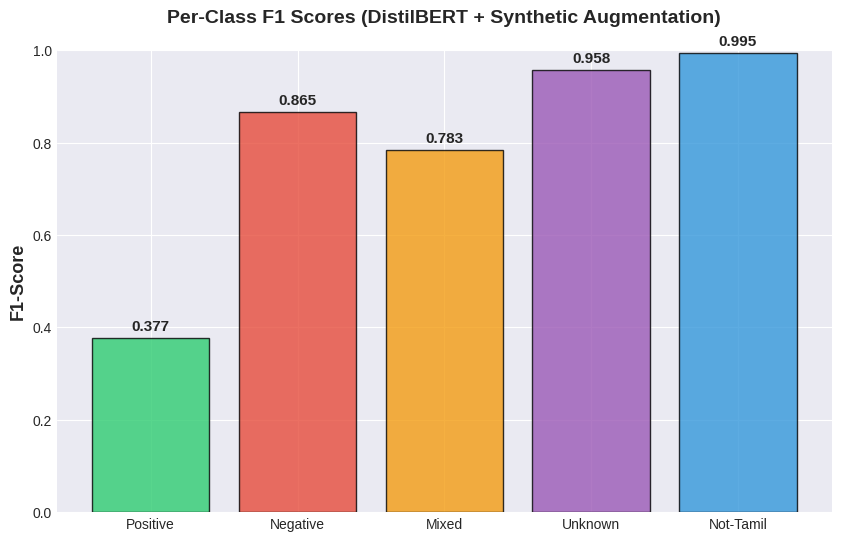

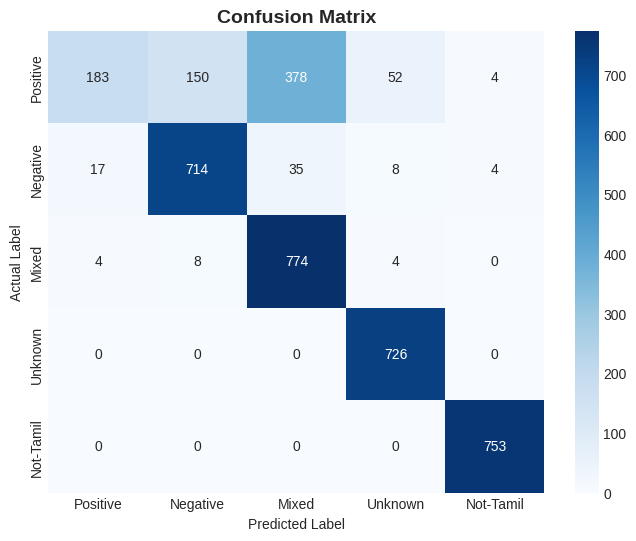

In [ ]:
print("="*60)
print("📊 FINAL EVALUATION (Test Set)")
print("="*60)

# 1. Predictions
predictions_output = trainer.predict(tokenized_ds['test'])
predictions = predictions_output.predictions.argmax(axis=-1)
true_labels = predictions_output.label_ids

# 2. Metrics
test_accuracy = accuracy_score(true_labels, predictions)
test_macro_f1 = f1_score(true_labels, predictions, average='macro')
class_names = ['Positive', 'Negative', 'Mixed', 'Unknown', 'Not-Tamil']

print(f"🎯 Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"🎯 Macro F1:  {test_macro_f1:.4f}")

# 3. Detailed Report
print("\n" + classification_report(true_labels, predictions, target_names=class_names, digits=4))

# 4. Per-Class Data for Plotting
precision, recall, f1_per_class, support = precision_recall_fscore_support(
    true_labels, predictions, labels=[0, 1, 2, 3, 4]
)

# --- PLOTTING (Restored Old Style) ---
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# Plot 1: Per-Class F1 Scores
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#3498db']
bars = ax.bar(class_names, f1_per_class, color=colors, alpha=0.8, edgecolor='black')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_ylabel('F1-Score', fontsize=13, fontweight='bold')
ax.set_title(f'Per-Class F1 Scores (DistilBERT + Synthetic Augmentation)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, 1.0)
plt.show()

# Plot 2: Confusion Matrix
cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()